# Renda por zona OD — amostra do Censo 2022

Estima a **renda domiciliar per capita média** de cada zona da Pesquisa OD 2023 a partir dos
microdados da amostra do Censo 2022 e classifica as zonas em **quintis de renda**. O resultado
substitui o antigo critério de distância à Praça da Sé em `periferia_tier`
(`03_comparacoes/compara_demanda_oferta_genero_idade.ipynb`, Seção 2).

A amostra só identifica a **área de ponderação (AP)**, não o setor. O caminho até a zona é:

1. renda média por AP, direto do microdado;
2. cada setor censitário herda a renda da sua AP e cai em uma zona OD (ponto representativo);
3. a renda da zona é a média dos seus setores, ponderada pelos moradores do Universo.

**Microdado de acesso controlado.** O zip em `Dados/` não pode ser versionado nem publicado. Este
notebook só grava e imprime **agregados** por AP ou zona — nenhuma célula deve exibir registros
individuais.

Insumos em `../Dados/censo_2022/` (procedência em `fonte.txt`). Consome também
`../outputs/01/Dados_4Meses_2023_2024_mes.parquet` e `../outputs/01/Dados_Domingos_2023_2024.parquet`,
só para saber quais zonas têm demanda.

## Seção 0 — imports e configuração

In [1]:
import zipfile
from pathlib import Path

import duckdb
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd
import polars as pl

In [2]:
CRS_LOCAL_UTM = 31983  # SIRGAS 2000 / UTM zone 23S
CD_UF = "35"
N_MIN_REGISTROS = 30   # APs com menos domicilios na amostra saem como NaN
N_QUINTIS = 5
ROTULOS_QUINTIL = ["Q1 (menor renda)", "Q2", "Q3", "Q4", "Q5 (maior renda)"]

DIR_CENSO = Path("../Dados/censo_2022")
ZIP_MICRODADOS = Path("../Dados/microdados_censo_amostra_2022_csv_20260923_175502.zip")
CSV_DOMICILIOS = f"{CD_UF}/Domicilios_{CD_UF}_controlado.csv"
SHP_ZONAS = Path("../Dados/pacote-anexos-od_10-02-25_0/002_Site Metro Mapas/Shape/Zonas_2023.shp")

DIR_SAIDA = Path("../outputs/01")

## Seção 1 — renda por área de ponderação

Universo: domicílios particulares permanentes ocupados (`D0130 = 01`) com rendimento per capita
informado (`D0360`) — a mesma definição da página de rendimento do `cn22-amo`.

A média é ponderada por **pessoas** (`D0111 × moradores`), porque é uma renda per capita: assim ela
equivale à renda total da AP dividida pelos seus moradores. A versão ponderada por domicílio e a
mediana ficam ao lado, para validação contra o indicador já publicado no `cn22-amo`.

In [3]:
COLUNAS = ["D0090", "D0111", "D0130", "D0360", "D0370", "D0380"]

with zipfile.ZipFile(ZIP_MICRODADOS) as z:
    dom = pl.read_csv(z.read(CSV_DOMICILIOS), separator=";", columns=COLUNAS, infer_schema_length=0)

numero = lambda c: pl.col(c).str.replace(",", ".").cast(pl.Float64, strict=False)
dom = (
    dom.select(
        pl.col("D0090").alias("cd_ap"),
        numero("D0111").alias("peso"),
        numero("D0130").alias("especie"),
        numero("D0360").alias("renda_pc"),
        (numero("D0370").fill_null(0) + numero("D0380").fill_null(0)).alias("moradores"),
    )
    .filter((pl.col("especie") == 1) & pl.col("renda_pc").is_not_null())
    .with_columns((pl.col("peso") * pl.col("moradores")).alias("peso_pessoas"))
)
print(f"domicilios na amostra (UF {CD_UF}, particulares permanentes ocupados): {dom.height:,}")
print(f"domicilios expandidos: {dom['peso'].sum():,.0f} | moradores expandidos: {dom['peso_pessoas'].sum():,.0f}")

domicilios na amostra (UF 35, particulares permanentes ocupados): 1,348,152
domicilios expandidos: 16,227,792 | moradores expandidos: 44,128,249


In [4]:
def mediana_ponderada(valor, peso):
    ordem = np.argsort(valor)
    acumulado = np.cumsum(peso[ordem])
    return valor[ordem][np.searchsorted(acumulado, acumulado[-1] / 2)]


renda_ap = (
    dom.group_by("cd_ap")
    .agg(
        n_registros=pl.len(),
        domicilios=pl.col("peso").sum(),
        moradores=pl.col("peso_pessoas").sum(),
        renda_pc_media=(pl.col("renda_pc") * pl.col("peso_pessoas")).sum() / pl.col("peso_pessoas").sum(),
        renda_pc_media_dom=(pl.col("renda_pc") * pl.col("peso")).sum() / pl.col("peso").sum(),
    )
    .to_pandas()
    .set_index("cd_ap")
    .sort_index()
)
renda_ap["renda_pc_mediana"] = (
    dom.select("cd_ap", "renda_pc", "peso").to_pandas()
    .groupby("cd_ap")[["renda_pc", "peso"]]
    .apply(lambda g: mediana_ponderada(g["renda_pc"].to_numpy(), g["peso"].to_numpy()))
)

poucos = renda_ap["n_registros"] < N_MIN_REGISTROS
renda_ap.loc[poucos, ["renda_pc_media", "renda_pc_media_dom", "renda_pc_mediana"]] = np.nan
print(f"APs na UF: {len(renda_ap)} | com menos de {N_MIN_REGISTROS} registros (suprimidas): {poucos.sum()}")
renda_ap.describe().round(1)

APs na UF: 2520 | com menos de 30 registros (suprimidas): 0

,n_registros,domicilios,moradores,renda_pc_media,renda_pc_media_dom,renda_pc_mediana
count,2520.0,2520.0,2520.0,2520.0,2520.0,2520.0
mean,535.0,6439.6,17511.2,1955.6,2170.5,1594.4
std,134.3,4067.7,10985.9,1338.8,1412.6,891.3
min,163.0,322.0,907.0,570.1,665.2,550.0
25%,430.8,4229.5,11252.1,1292.7,1453.0,1200.0
50%,495.0,5212.5,14355.5,1545.0,1728.2,1300.0
75%,613.0,8183.5,22729.8,2087.9,2329.4,1660.0
max,1453.0,23286.0,62269.6,15727.0,14988.0,8950.0


In [5]:
# Validacao: o mesmo indicador, calculado em R no cn22-amo (media ponderada por domicilio e mediana).
ref = pd.read_csv(DIR_CENSO / "rendimento_ap_cn22amo.csv", dtype={"geo": str})
ref = ref[ref["indicador"].isin(["renda_dom_media", "renda_dom_mediana"])].pivot(
    index="geo", columns="indicador", values="valor")

val = renda_ap.join(ref, how="inner")
for nosso, deles in [("renda_pc_media_dom", "renda_dom_media"), ("renda_pc_mediana", "renda_dom_mediana")]:
    dif = (val[nosso] / val[deles] - 1).abs()
    print(f"{nosso} x {deles}: {len(val)} APs | correlacao {val[nosso].corr(val[deles]):.5f} | "
          f"diferenca abs. mediana {100 * dif.median():.3f}% | maxima {100 * dif.max():.3f}%")

razao = val["renda_pc_media"] / val["renda_pc_media_dom"]
print(f"media por pessoas / media por domicilio: mediana {razao.median():.3f} "
      f"(p5 {razao.quantile(.05):.3f}, p95 {razao.quantile(.95):.3f}) | "
      f"correlacao {val['renda_pc_media'].corr(val['renda_pc_media_dom']):.4f}")
assert val["renda_pc_media_dom"].corr(val["renda_dom_media"]) > 0.95

renda_pc_media_dom x renda_dom_media: 2520 APs | correlacao 1.00000 | diferenca abs. mediana 0.000% | maxima 0.000%
renda_pc_mediana x renda_dom_mediana: 2520 APs | correlacao 1.00000 | diferenca abs. mediana 0.000% | maxima 0.000%
media por pessoas / media por domicilio: mediana 0.894 (p5 0.849, p95 0.940) | correlacao 0.9958


## Seção 2 — setor censitário → zona OD e → AP

A ponte entre as duas malhas é o **setor censitário**: ele pertence a exatamente uma AP
(`composicao_ap`) e é pequeno o bastante para ser atribuído a uma única zona OD pelo seu ponto
representativo. O peso é o número de moradores do setor no Universo (`V06002`).

Só entram as zonas **com demanda** na bilhetagem — é sobre elas que os quintis são cortados.

In [6]:
zonas = gpd.read_file(SHP_ZONAS).to_crs(CRS_LOCAL_UTM)

zonas_demanda = duckdb.sql('''
    SELECT DISTINCT zona_emb FROM '../outputs/01/Dados_4Meses_2023_2024_mes.parquet'
    WHERE zona_emb IS NOT NULL
    UNION
    SELECT DISTINCT zona_emb FROM '../outputs/01/Dados_Domingos_2023_2024.parquet'
    WHERE zona_emb IS NOT NULL AND zona_emb <> 999 AND linha_blt IS NOT NULL
''').df()["zona_emb"]

zonas_dem = zonas[zonas["NumeroZona"].isin(zonas_demanda)].copy()
print(f"zonas OD: {len(zonas)} | com demanda na bilhetagem: {zonas_demanda.nunique()} | "
      f"dessas, presentes no shape: {len(zonas_dem)}")

zonas OD: 527 | com demanda na bilhetagem: 355 | dessas, presentes no shape: 355


In [7]:
setores = gpd.read_file(
    DIR_CENSO / "SP_setores_CD2022.gpkg", columns=["CD_SETOR"],
    bbox=tuple(zonas_dem.to_crs(4674).total_bounds),
).to_crs(CRS_LOCAL_UTM)
setores["geometry"] = setores.representative_point()

setor_zona = gpd.sjoin(setores, zonas_dem[["NumeroZona", "geometry"]], predicate="within")[
    ["CD_SETOR", "NumeroZona"]]

composicao = pd.read_parquet(DIR_CENSO / "composicao_ap.parquet", columns=["cd_setor", "cd_ap"])

csv_universo = (DIR_CENSO / "Agregados_por_setores_renda_responsavel_BR.csv").as_posix()
universo = duckdb.sql(f'''
    SELECT CD_SETOR,
           TRY_CAST(V06001 AS DOUBLE) AS responsaveis,
           TRY_CAST(V06002 AS DOUBLE) AS moradores,
           TRY_CAST(REPLACE(V06004, ',', '.') AS DOUBLE) AS renda_resp
    FROM read_csv('{csv_universo}', delim=';', all_varchar=true)
    WHERE CD_SETOR LIKE '{CD_UF}%'
''').df()

base = (
    setor_zona
    .merge(composicao, left_on="CD_SETOR", right_on="cd_setor", how="left")
    .merge(universo, on="CD_SETOR", how="left")
    .merge(renda_ap[["renda_pc_media", "renda_pc_mediana"]], left_on="cd_ap", right_index=True, how="left")
)
base["moradores"] = base["moradores"].fillna(0)

print(f"setores dentro das zonas com demanda: {len(base):,}")
print(f"  sem AP na composicao: {base['cd_ap'].isna().sum()} | "
      f"sem renda da AP: {base['renda_pc_media'].isna().sum()} | "
      f"sem moradores no Universo: {(base['moradores'] == 0).sum()}")
print(f"APs que tocam essas zonas: {base['cd_ap'].nunique()} | moradores: {base['moradores'].sum():,.0f}")

setores dentro das zonas com demanda: 29,657
  sem AP na composicao: 0 | sem renda da AP: 1 | sem moradores no Universo: 688
APs que tocam essas zonas: 408 | moradores: 12,460,899


## Seção 3 — renda por zona e quintis

`renda_pc_media` da zona = média das APs que a compõem, ponderada pelos moradores dos setores.
`share_ap_dominante` e `n_ap` medem o quanto a zona é uma mistura de APs.

Os quintis são cortados **por número de zonas** (`pd.qcut`): cada quintil tem ~1/5 das zonas com
demanda, não 1/5 dos moradores.

In [8]:
def media_ponderada(g, coluna, peso="moradores"):
    g = g.dropna(subset=[coluna])
    return np.average(g[coluna], weights=g[peso]) if g[peso].sum() > 0 else np.nan


zona_ap = base.groupby(["NumeroZona", "cd_ap"])["moradores"].sum().reset_index()
zona_ap["share"] = zona_ap["moradores"] / zona_ap.groupby("NumeroZona")["moradores"].transform("sum")

grupos = base.groupby("NumeroZona")[["moradores", "renda_pc_media", "renda_pc_mediana"]]
renda_zona = pd.DataFrame({
    "pop": base.groupby("NumeroZona")["moradores"].sum(),
    "renda_pc_media": grupos.apply(lambda g: media_ponderada(g, "renda_pc_media")),
    "renda_pc_mediana": grupos.apply(lambda g: media_ponderada(g, "renda_pc_mediana")),
    "n_ap": zona_ap.groupby("NumeroZona")["cd_ap"].nunique(),
    "share_ap_dominante": zona_ap.groupby("NumeroZona")["share"].max(),
})

renda_zona["quintil_renda"] = pd.qcut(renda_zona["renda_pc_media"], N_QUINTIS, labels=ROTULOS_QUINTIL)

sem_renda = sorted(set(zonas_demanda) - set(renda_zona.dropna(subset=["renda_pc_media"]).index))
print(f"zonas com renda: {renda_zona['renda_pc_media'].notna().sum()} | "
      f"zonas com demanda e sem renda: {len(sem_renda)} {sem_renda}")
print("\nComposicao das zonas por AP (ponderada por moradores):")
print(renda_zona[["n_ap", "share_ap_dominante"]].describe().round(2).to_string())

zonas com renda: 355 | zonas com demanda e sem renda: 0 []

Composicao das zonas por AP (ponderada por moradores):
         n_ap  share_ap_dominante
count  355.00              355.00
mean     2.02                0.81
std      1.37                0.23
min      1.00                0.17
25%      1.00                0.62
50%      2.00                0.94
75%      2.00                1.00
max     12.00                1.00


                  zonas  moradores  renda_min  renda_media  renda_max  pct_moradores
quintil_renda                                                                       
Q1 (menor renda)     71  4589640.0      881.0       1168.0     1382.0           37.0
Q2                   71  3195975.0     1383.0       1634.0     2080.0           26.0
Q3                   71  2159606.0     2084.0       2635.0     3426.0           17.0
Q4                   71  1464815.0     3510.0       4639.0     6453.0           12.0
Q5 (maior renda)     71  1050863.0     6487.0       9434.0    15727.0            8.0


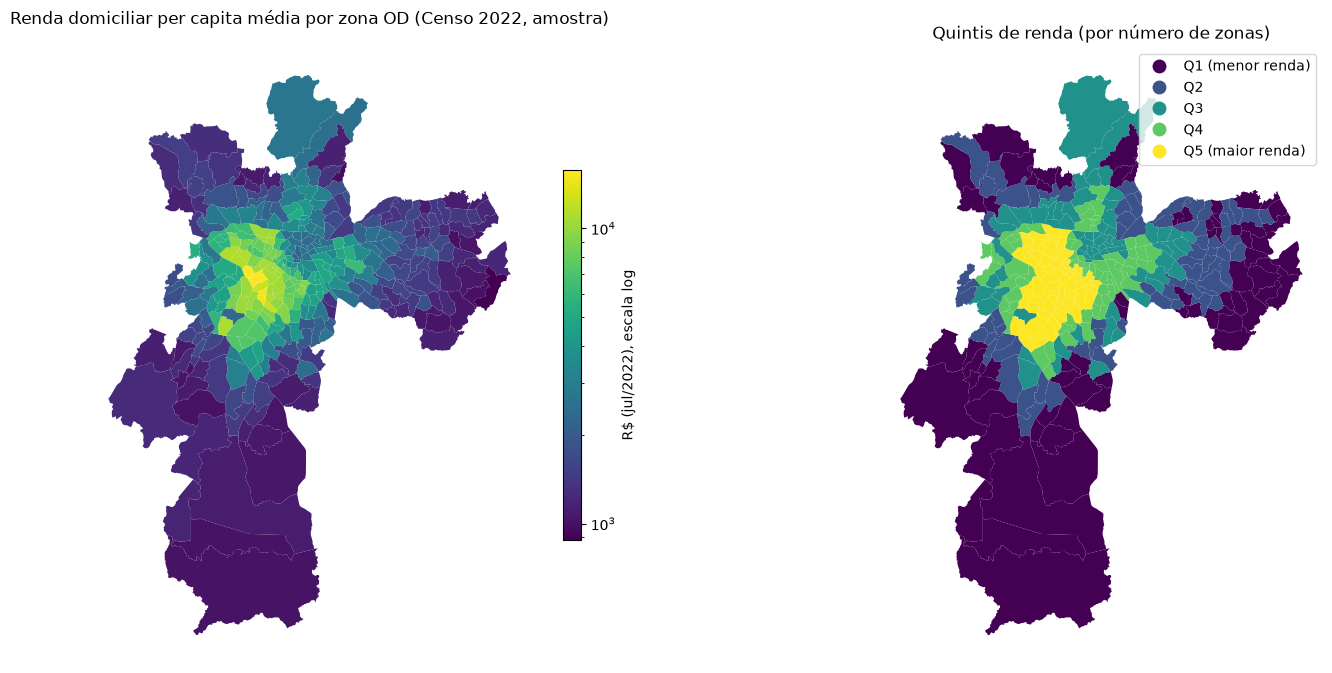

In [9]:
resumo_quintil = renda_zona.groupby("quintil_renda", observed=True).agg(
    zonas=("pop", "size"),
    moradores=("pop", "sum"),
    renda_min=("renda_pc_media", "min"),
    renda_media=("renda_pc_media", "mean"),
    renda_max=("renda_pc_media", "max"),
)
resumo_quintil["pct_moradores"] = 100 * resumo_quintil["moradores"] / resumo_quintil["moradores"].sum()
print(resumo_quintil.round(0).to_string())

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
mapa = zonas_dem.merge(renda_zona, left_on="NumeroZona", right_index=True, how="left")
mapa.plot(column="renda_pc_media", cmap="viridis", norm=LogNorm(), legend=True,
          legend_kwds={"label": "R$ (jul/2022), escala log", "shrink": 0.6},
          missing_kwds={"color": "lightgrey"}, ax=axes[0])
axes[0].set_title("Renda domiciliar per capita média por zona OD (Censo 2022, amostra)")
mapa.plot(column="quintil_renda", categorical=True, cmap="viridis", legend=True,
          missing_kwds={"color": "lightgrey"}, ax=axes[1])
axes[1].set_title("Quintis de renda (por número de zonas)")
for ax in axes:
    ax.set_axis_off()
plt.show()

## Seção 4 — quanto se perde por a amostra estar em AP?

Teste com uma variável que existe nas **duas** resoluções: o rendimento médio do responsável pelo
domicílio, do Universo, publicado por setor (`V06004`). Calcula-se a renda da zona de dois jeitos:

- **direto**: média dos setores da zona — a resolução que gostaríamos de ter;
- **via AP**: cada setor recebe a média da sua AP inteira, depois agrega para a zona — exatamente a
  operação que a Seção 3 faz com a amostra.

A diferença entre os dois é a perda de resolução atribuível à AP, isolada de qualquer diferença de
conceito de renda.

In [10]:
aps_usadas = base["cd_ap"].dropna().unique()
setores_ap = composicao[composicao["cd_ap"].isin(aps_usadas)].merge(
    universo, left_on="cd_setor", right_on="CD_SETOR").dropna(subset=["renda_resp", "responsaveis"])
resp_ap = setores_ap.groupby("cd_ap")[["renda_resp", "responsaveis"]].apply(
    lambda g: np.average(g["renda_resp"], weights=g["responsaveis"])).rename("resp_ap")

teste = base.merge(resp_ap, left_on="cd_ap", right_index=True, how="left")
teste["responsaveis"] = teste["responsaveis"].fillna(0)
resolucao = pd.DataFrame({
    "direto": teste.groupby("NumeroZona")[["renda_resp", "responsaveis"]].apply(
        lambda g: media_ponderada(g, "renda_resp", "responsaveis")),
    "via_ap": teste.groupby("NumeroZona")[["resp_ap", "moradores"]].apply(
        lambda g: media_ponderada(g, "resp_ap")),
}).dropna()

quintil = lambda s: pd.qcut(s, N_QUINTIS, labels=False)
salto = (quintil(resolucao["direto"]) - quintil(resolucao["via_ap"])).abs()

print(f"zonas avaliadas: {len(resolucao)}")
print(f"correlacao de Spearman direto x via AP: {resolucao.corr(method='spearman').iloc[0, 1]:.3f}")
print(f"mesmo quintil: {100 * (salto == 0).mean():.1f}% | quintil vizinho: {100 * (salto == 1).mean():.1f}% | "
      f"dois ou mais: {100 * (salto >= 2).mean():.1f}%")
print(f"dispersao entre zonas preservada (DP do log, via AP / direto): "
      f"{np.log(resolucao['via_ap']).std() / np.log(resolucao['direto']).std():.3f}")

comum = resolucao.join(renda_zona["renda_pc_media"]).dropna()
print(f"Spearman renda do responsavel (Universo, direto) x renda per capita (amostra, via AP): "
      f"{comum[['direto', 'renda_pc_media']].corr(method='spearman').iloc[0, 1]:.3f}")

zonas avaliadas: 355
correlacao de Spearman direto x via AP: 0.962
mesmo quintil: 83.9% | quintil vizinho: 14.6% | dois ou mais: 1.4%
dispersao entre zonas preservada (DP do log, via AP / direto): 0.969
Spearman renda do responsavel (Universo, direto) x renda per capita (amostra, via AP): 0.957


## Seção 5 — gravação

In [11]:
DIR_SAIDA.mkdir(parents=True, exist_ok=True)

renda_ap_saida = renda_ap.loc[renda_ap.index.isin(aps_usadas)].reset_index()
renda_ap_saida.to_parquet(DIR_SAIDA / "renda_ap_censo2022.parquet", index=False)

renda_zona_saida = renda_zona.reset_index()
renda_zona_saida.to_parquet(DIR_SAIDA / "renda_zona_censo2022.parquet", index=False)

print(f"renda_ap_censo2022.parquet: {len(renda_ap_saida)} APs")
print(f"renda_zona_censo2022.parquet: {len(renda_zona_saida)} zonas")
renda_zona_saida.head()

renda_ap_censo2022.parquet: 407 APs
renda_zona_censo2022.parquet: 355 zonas


,NumeroZona,pop,renda_pc_media,renda_pc_mediana,n_ap,share_ap_dominante,quintil_renda
0,1,3207.0,2223.355732,1900.0,1,1.0,Q3
1,2,3614.0,2223.355732,1900.0,1,1.0,Q3
2,3,15949.0,2223.355732,1900.0,1,1.0,Q3
3,4,23672.0,4797.546510,4000.0,1,1.0,Q4
4,5,13904.0,3221.564345,2800.0,1,1.0,Q3
